In [47]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import json
from scipy import interpolate
from skimage import io
import imageio.v3 as iio

In [48]:
def get_automated_paths_and_number(image_path):
    """
    Extracts the frame number from the image filename and automatically 
    locates the companion JSON config file within the same directory.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        tuple: (int: image_number, str: json_path)
    """
    image_dir = os.path.dirname(image_path)
    file_name = os.path.basename(image_path)
    
    # Extract image sequence number 
    try:
        number_string = file_name.split('_')[1].split('.')[0]
        image_number = int(number_string)
    except (IndexError, ValueError):
        raise ValueError(f"Could not parse image number from filename: {file_name}. Expected format: prefix_0000.png")
        
    # Automatically locate the JSON file in the same directory
    json_files = glob.glob(os.path.join(image_dir, "*.json"))
    if not json_files:
        raise FileNotFoundError(f"No JSON configuration file found in: {image_dir}")
        
    json_path = json_files[0]
    return image_number, json_path


In [49]:
def load_image(image_path):
    """
    Loads an image from a given file path.

    Args:
        image_path (str): The complete path to the image file.

    Returns:
        numpy.ndarray: The loaded image as an array of pixels.
    """
    image = io.imread(image_path)
    return image

In [50]:
def load_json(file_path):
    """
    Loads a JSON file and returns its content.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        list/dict: The parsed JSON data.
    """
    with open(file_path, "r", encoding="utf-8") as file:
        data = json.load(file)
    
    return data

In [51]:
def get_defect_coordinates(json_data, image_number):
    """
    Parses JSON data to extract defect coordinates for a specific image number.

    Args:
        json_data (list): The list of dictionaries loaded from the JSON file.
        image_number (str or int): The specific image number to look for in the JSON.

    Returns:
        dict: A dictionary where keys are x-coordinates (columns) and values 
              are dictionaries containing lists of 'start' and 'stop' y-coordinates.
    """
    defect_dict = {}
    
    for item in json_data:
        value = item.get('signal', {}).get(str(image_number))
        
        if value is not None:
            for x_coord in item.get('x_coord', []):
                
                defect_dict[x_coord] = {
                    'start': item.get('y_start', []), 
                    'stop': item.get('y_stop', [])
                }

    return defect_dict

In [52]:
def normalize_to_8bit(image_array):
    """
    Normalizes an image array (e.g., 16-bit) to an 8-bit range (0 to 255).

    Args:
        image_array (numpy.ndarray): The input image array.

    Returns:
        numpy.ndarray: The normalized image array with dtype uint8.
    """
    img_np = np.array(image_array, dtype=np.float32)
    
    val_min = np.min(img_np)
    val_max = np.max(img_np)
    
    if val_max == val_min:
        return np.zeros_like(img_np, dtype=np.uint8)
        
    normalized_image = ((img_np - val_min) / (val_max - val_min)) * 255
    
    return normalized_image.astype(np.uint8)

In [53]:
# def normalize_to_8bit(image_array):
#     """""
#     Convert 16 bits img into 8 bits using percentiles to not be biased by outliers  
#     arg : img 
#     return : converted img in 8 bits
#     """""
#     p2, p98 = np.percentile(image_array, (2, 98))
#     img_clipped = np.clip(image_array, p2, p98)
    
#     # 2. Normaliser entre 0 et 255
#     normalized_image = ((img_clipped - p2) / (p98 - p2) * 255).astype(np.uint8)
#     return normalized_image

In [54]:
def interpolate_inside_stripe(mat, list_mask, kind="linear"):
    """
    Interpolate gray-scales inside vertical stripes of an image. Stripe
    locations given by a binary 1D-mask.

    Args: 
        mat : array_like 2D array.
        list_mask : array_like 1D array. Must equal the width of an image.
        kind : {'linear', 'cubic', 'quintic'}, optional
            The kind of spline interpolation to use. Default is 'linear'.

    Returns:
        array_like
    """
    (nrow, ncol) = mat.shape
    if len(list_mask) != ncol:
        raise ValueError("Length of a binary 1D-mask is not the same as the "
                         "width of an image!")
    mat = np.copy(mat)
    list_mask = np.copy(list_mask)
    list_mask[0:2] = 0.0
    list_mask[-2:] = 0.0
    xlist = np.where(list_mask < 1.0)[0]
    ylist = np.arange(nrow)
    if kind == "cubic":
        finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist],
                                                 kx=2, ky=2)
    elif kind == "quintic":
        finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist],
                                                 kx=3, ky=3)
    else:
        finter = interpolate.RectBivariateSpline(ylist, xlist, mat[:, xlist],
                                                 kx=1, ky=1)
    xlist_miss = np.where(list_mask > 0.0)[0]
    if len(xlist_miss) > 0:
        x_mat_miss, y_mat = np.meshgrid(xlist_miss, ylist)
        output = finter.ev(np.ndarray.flatten(y_mat),
                           np.ndarray.flatten(x_mat_miss))
        mat[:, xlist_miss] = output.reshape(x_mat_miss.shape)
    return mat

In [55]:
def create_stripe_mask(defect_coordinates, image_width):
    """
    Converts defect coordinates dictionary into a 1D binary mask 
    required for the Algotom destriping function.

    Args:
        defect_coordinates (dict): Result from get_defect_coordinates.
        image_width (int): The width (ncol) of the 16-bit image.

    Returns:
        numpy.ndarray: 1D array of size (image_width,) where 1 represents a defective column.
    """
    list_mask = np.zeros(image_width, dtype=np.uint8)
    
    for x_coord in defect_coordinates.keys():
        x = int(x_coord)
        if 0 <= x < image_width:
            list_mask[x] = 1
            
    return list_mask

In [56]:
def display_comparison(original_image, processed_image):
    """
    Normalizes 16-bit images to 8-bit and plots them side-by-side for comparison.
    Uses the pre-existing normalize_to_8bit function.

    Args:
        original_image (numpy.ndarray): The raw original 16-bit image array.
        processed_image (numpy.ndarray): The destriped 16-bit image array.
    """
    # Scale both images to 8-bit strictly for rendering pipeline
    original_image_8bits = normalize_to_8bit(original_image)
    processed_image_8bits = normalize_to_8bit(processed_image)

    fig, axes = plt.subplots(1, 2, figsize=(14, 7))

    # Plot 1: The original corrupted image
    axes[0].imshow(original_image_8bits, cmap='gray')
    axes[0].set_title("Original Image", fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Plot 2: The destriped image processed by Algotom
    axes[1].imshow(processed_image_8bits, cmap='gray')
    axes[1].set_title("Corrected image", fontsize=12, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [57]:
def get_automated_save_path(image_path):
    """
    Automatically constructs a save path inside a 'result_method_interpolation' subfolder 
    located in the same directory as the input image, keeping the original filename.

    Args:
        image_path (str): The complete path to the input image file.

    Returns:
        str: The absolute path to save the processed image.
    """
    # Find the directory containing the original image
    image_dir = os.path.dirname(image_path)
    
    # Get the original image filename (e.g., "frame_0043.png")
    filename = os.path.basename(image_path)
    
    # Create the path to the new directory according to your needs
    result_dir = os.path.join(image_dir, "result_method_interpolation")
    
    # Combine everything back into a complete file path
    automated_save_path = os.path.join(result_dir, filename)
    
    return automated_save_path

In [58]:
def pipeline_process_image(image_path, show_result=True):
    """
    Executes the complete processing block using isolated sub-functions.
    Calculates directly on the 16-bit native space and automatically saves the output.

    Args:
        image_path (str): The complete path to the input image file.
        show_result (bool): If True, displays the side-by-side comparison.

    Returns:
        numpy.ndarray: The pristine destriped 16-bit image array.
    """
    # Automatically detect frame number and JSON configuration path
    image_number, json_path = get_automated_paths_and_number(image_path)
    
    # Load original 16-bit image and JSON defect data 
    original_image = load_image(image_path)
    json_data = load_json(json_path)
    
    # Extract defect coordinates for the specific image number
    defect_coords = get_defect_coordinates(json_data, image_number)
    
    # Construct the 1D Mask array based on image width
    image_width = original_image.shape[1]
    list_mask = create_stripe_mask(defect_coords, image_width)

    
    # Use Algotom's cubic interpolation 
    corrected_image_16bit = interpolate_inside_stripe(original_image, list_mask)
    
    # Generate the automated save path (.../result_method_interpolation/frame_XXXX.png)
    automated_save_path = get_automated_save_path(image_path)
    
    # Ensure the output directory exists, create it if missing
    output_dir = os.path.dirname(automated_save_path)
    if output_dir and not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created new directory file: {output_dir}")
        
    # Save the corrected image in 16-bit format 
    iio.imwrite(automated_save_path, corrected_image_16bit)
    print(f"Successfully saved image automatically to: {automated_save_path}")
    
    # Display
    if show_result:
        display_comparison(original_image, corrected_image_16bit)
        
    return corrected_image_16bit

Successfully saved image automatically to: /Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/SXGA/sequence_1/low dyn with columns 2/result_method_interpolation/frame_0046.png


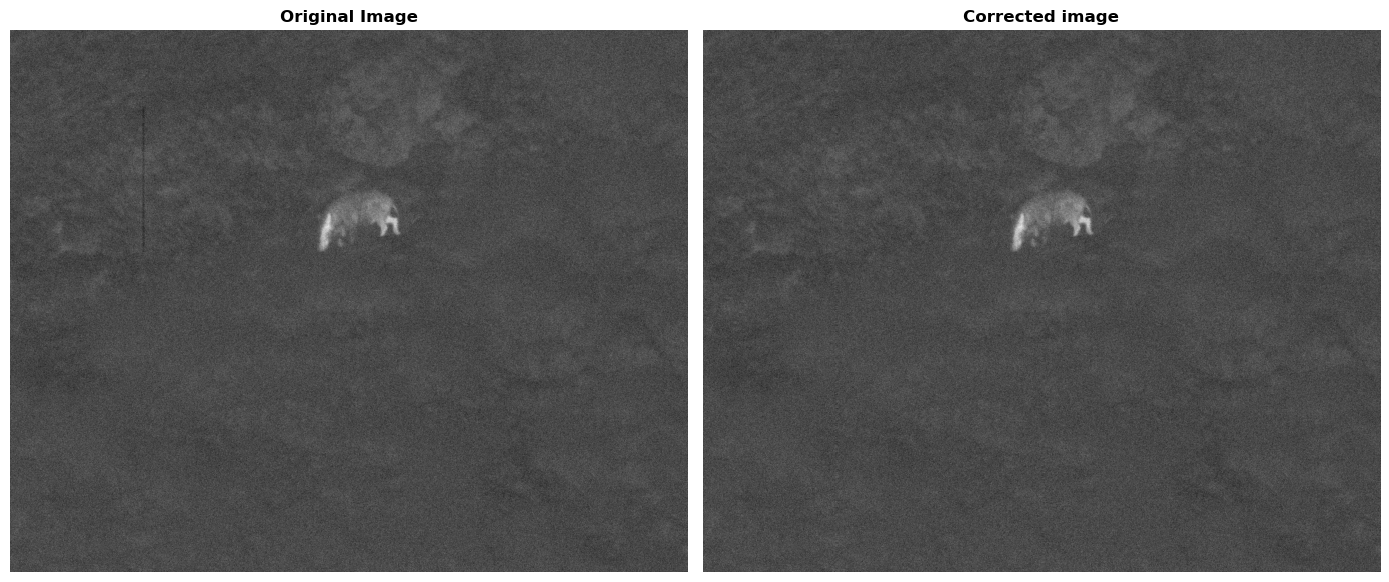

In [59]:
image_file = "/Users/thanhhiennguyenle/Documents/Data Challenge - Defective columns 2026/train/SXGA/sequence_1/low dyn with columns 2/frame_0046.png"

# Run the entire automated module pipeline
final_image_16bit = pipeline_process_image(image_file, show_result=True)